# IPL 2022 Capstone Project

The **Indian Premier League (IPL)** is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

These are some of the important columns that we'll focus on for meaningful insights in this project.

## Column Names

| Column Name | Variable Type |
|--------------|---------------|
| date | string |
| venue | string |
| stage | string |
| team1 | string |
| team2 | string |
| toss_winner | string |
| toss_decision | string |
| first_ings_score | integer |
| second_ings_score | integer |
| match_winner | string |
| won_by | string |
| margin | integer |
| player_of_the_match | string |
| top_scorer | string |
| highscore | integer |
| best_bowling | string |
| best_bowling_fgure | string |




In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"IPL.csv")
import warnings
warnings.filterwarnings("ignore")

df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


### Basic Information

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [21]:
df.shape

(74, 20)

In [22]:
print(f"Number of rows: {df.shape[0]}and number of columns: {df.shape[1]}")

Number of rows: 74and number of columns: 20


In [23]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

### Basic Questions

### 1. Which team won the most matches?

Text(0, 0.5, 'Teams')

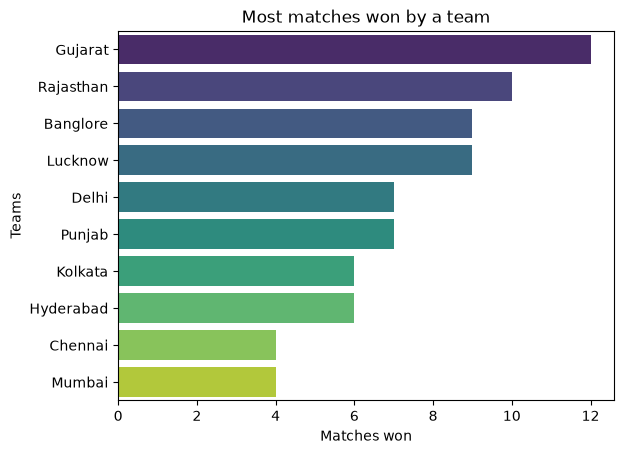

In [24]:
#Which team has won most matches
match_wins=df["match_winner"].value_counts()
sns.barplot(y=match_wins.index, x=match_wins.values,palette='viridis')
plt.title("Most matches won by a team")
plt.xlabel("Matches won")
plt.ylabel("Teams")

### 2. Toss Decision Trends

Text(0, 0.5, 'Number of matches')

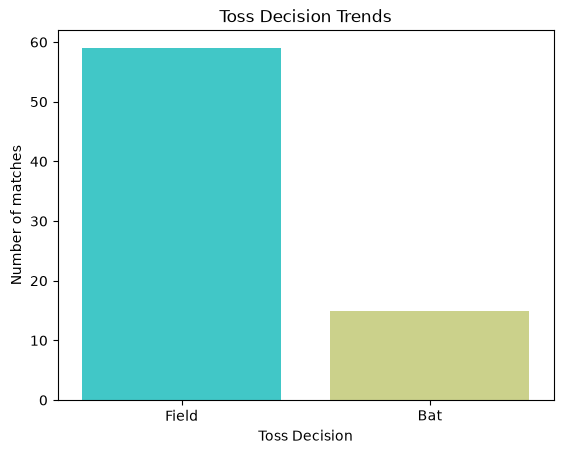

In [25]:
sns.countplot(x=df["toss_decision"],palette='rainbow')
plt.title("Toss Decision Trends")
plt.xlabel("Toss Decision")
plt.ylabel("Number of matches")

### 3. Toss winner vs match winner

In [26]:
count=df[df['toss_winner']== df['match_winner']]['match_id'].count()
percentage=(count*100)/df.shape[0]
percentage.__round__(2)

print(f'percentage of matches won by a team:{percentage.__round__(2)}')

percentage of matches won by a team:48.65


### 4. How do teams win? (Runs vs Wickets)

Text(0.5, 1.0, 'Won by')

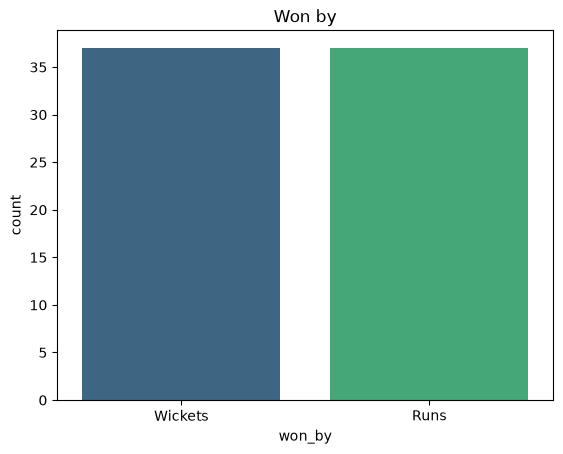

In [52]:
sns.countplot(x=df['won_by'],palette='viridis')
plt.title("Won by")

## Key Player performances

### 1. Most "Player of the Match" Awards

In [28]:
count=df['player_of_the_match'].value_counts().head(10)
count

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

Text(0, 0.5, 'Players')

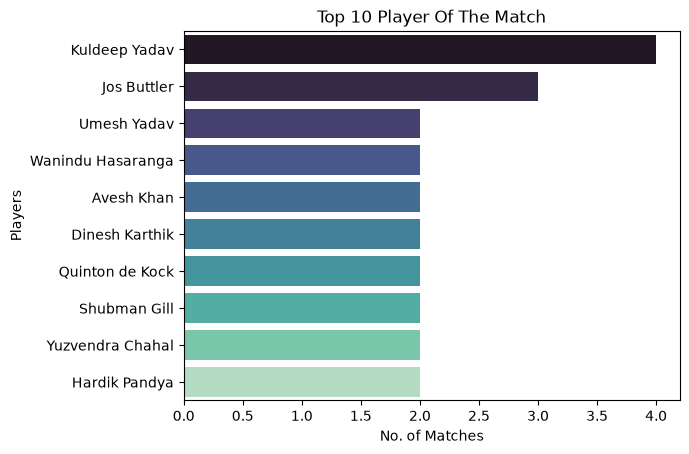

In [29]:
sns.barplot(x=count.values,y=count.index,palette='mako')
plt.title('Top 10 Player Of The Match')
plt.xlabel("No. of Matches")
plt.ylabel("Players")

### 2. Top Scorers

In [30]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head()
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Shubman Gill       288
Faf du Plessis     257
Name: highscore, dtype: int64

Text(0, 0.5, 'Players')

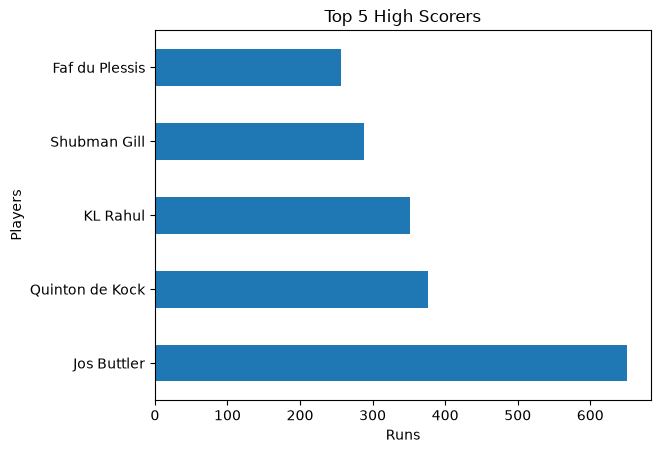

In [31]:
high.plot(kind='barh')
plt.title('Top 5 High Scorers')
plt.xlabel("Runs")
plt.ylabel("Players")

### 3. 10 Best Bowling Figures

<Axes: ylabel='best_bowling'>

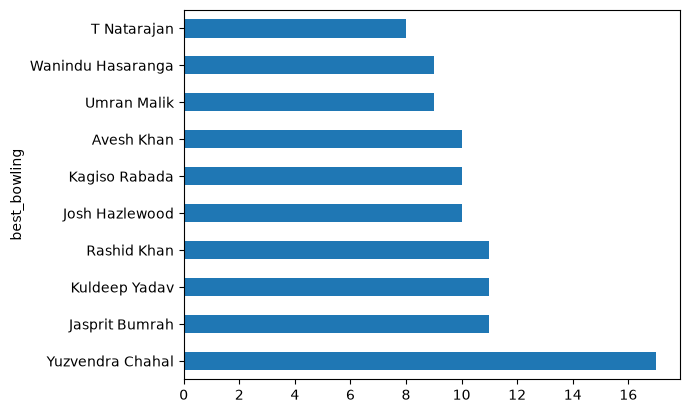

In [32]:
df['highest_wickets']= df['best_bowling_figure'].apply(lambda x : x.split('--')[0])
df['highest_wickets']= df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='barh')

## Venue Analysis

### Most Matches Played by Venue

<Axes: ylabel='venue'>

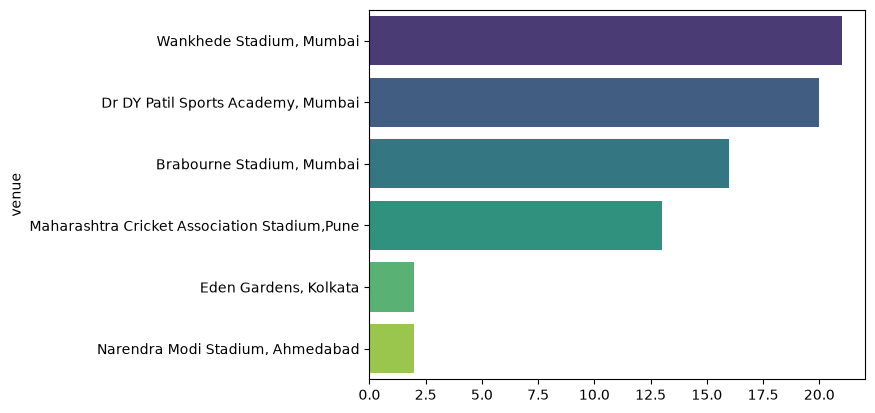

In [33]:
venue_count= df['venue'].value_counts()
sns.barplot(y=venue_count.index, x=venue_count.values,palette='viridis')

## Custom Questions & Insights

### Q1: Who won the highest margin by runs?

In [34]:
df[df["won_by"]== 'Runs'].sort_values(by='margin',ascending=False)[['match_winner','margin']].head(1)

,match_winner,margin
54,Chennai,91


### Q2: Which player had the highest individual score?

In [35]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


### Q3: Which bowler had the best bowling figures?

In [36]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10


## Some Extra Questions

### Which teams reached the playoffs?

In [46]:
qualified_teams=df[df['stage'] =='Playoff'][['team1','team2']]
qualified=pd.unique(qualified_teams.values.ravel())
print(qualified)

['Gujarat' 'Rajasthan' 'Banglore' 'Lucknow']


### Which toss decision resulted in more wins?

Text(0, 0.5, 'Number of Wins')

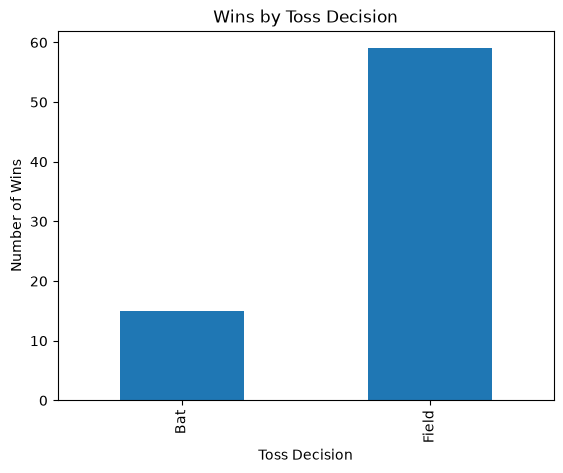

In [58]:
toss_wins = df.groupby("toss_decision")["match_winner"].count()

toss_wins.plot(kind="bar")
plt.title("Wins by Toss Decision")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Wins")

In [57]:
df.groupby("toss_decision")["match_winner"].count()

toss_decision
Bat      15
Field    59
Name: match_winner, dtype: int64

### Which venue had the highest average first-innings score?

Text(0.5, 0, 'avg. first-innings total')

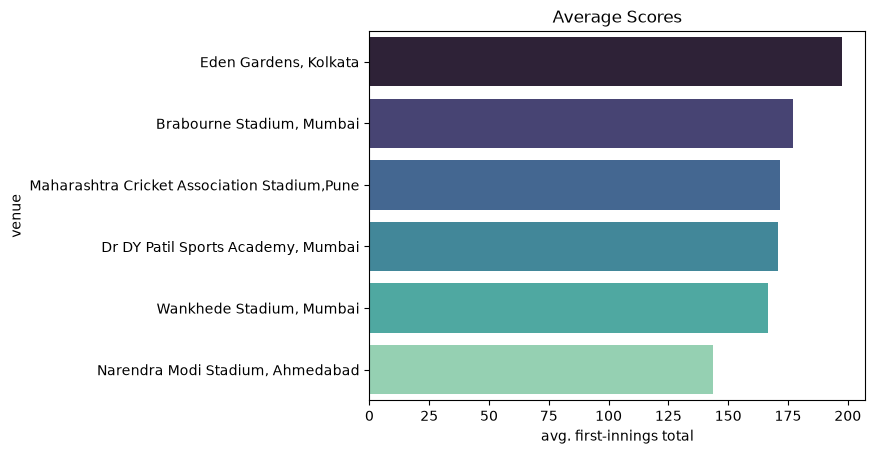

In [72]:
highestIst_avg=df.groupby('venue')['first_ings_score'].mean().sort_values(ascending= False)
sns.barplot(y=highestIst_avg.index,x=highestIst_avg.values,palette='mako')
plt.title('Average Scores')
plt.xlabel('avg. first-innings total')

### Which team won the most matches while batting first?

Text(0, 0.5, 'matches won')

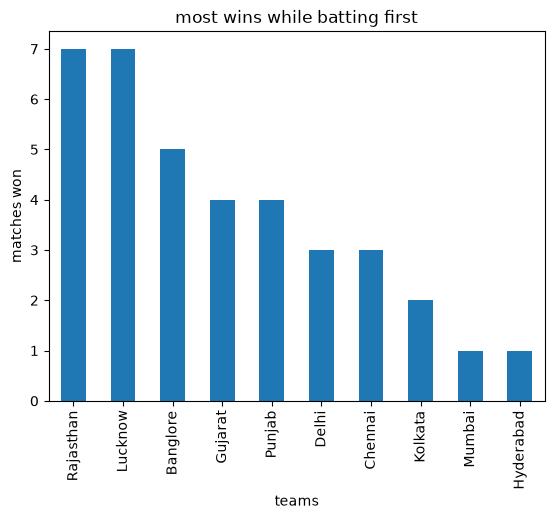

In [82]:
batting_first_wins = df[
    ((df["toss_winner"] == df["match_winner"]) & (df["toss_decision"] == "Bat")) |
    ((df["toss_winner"] != df["match_winner"]) & (df["toss_decision"] == "Field"))
]

batting_first_wins["match_winner"].value_counts().plot(kind='bar')
plt.title("most wins while batting first")
plt.xlabel("teams")
plt.ylabel("matches won")

### Which team won the most matches while chasing?

Text(0, 0.5, 'matches won')

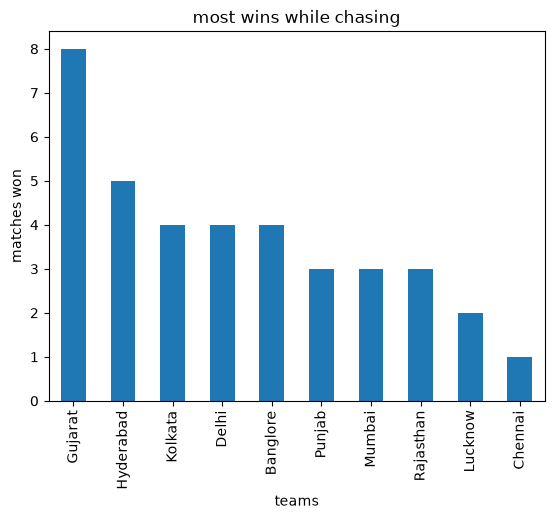

In [84]:
chasing_wins = df[
    ((df["toss_winner"] == df["match_winner"]) & (df["toss_decision"] == "Field")) |
    ((df["toss_winner"] != df["match_winner"]) & (df["toss_decision"] == "Bat"))
]

chasing_wins["match_winner"].value_counts().plot(kind='bar')
plt.title("most wins while chasing")
plt.xlabel("teams")
plt.ylabel("matches won")

### What was the biggest victory by runs?

In [108]:
highest_by_runs= df[df['won_by']== 'Runs'][['match_winner','margin']].sort_values(by='margin',ascending=False).head(5)
highest_by_runs


,match_winner,margin
54,Chennai,91
52,Lucknow,75
53,Banglore,67
56,Gujarat,62
4,Rajasthan,61


<Axes: xlabel='match_winner', ylabel='margin'>

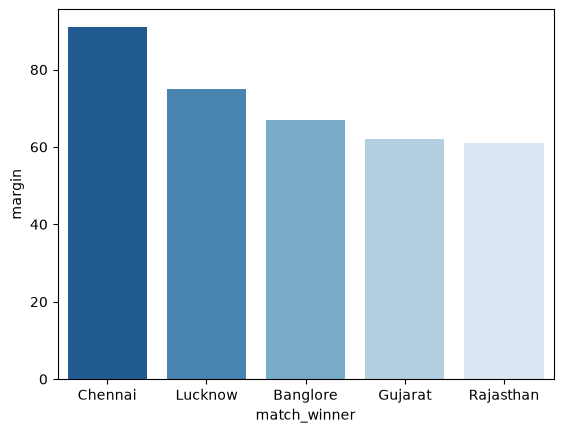

In [111]:
sns.barplot(x="match_winner",y='margin',data=highest_by_runs,palette="Blues_r")

### Which team had the highest average winning margin?

In [118]:
highest_average_win_margin= df[df['won_by'] == 'Runs'].groupby('match_winner')['margin'].mean().sort_values(ascending=False)
highest_average_win_margin

match_winner
Kolkata      53.000000
Chennai      42.333333
Punjab       32.750000
Gujarat      30.250000
Delhi        27.333333
Banglore     25.600000
Lucknow      24.142857
Rajasthan    23.142857
Mumbai        5.000000
Hyderabad     3.000000
Name: margin, dtype: float64

Text(0, 0.5, 'Teams')

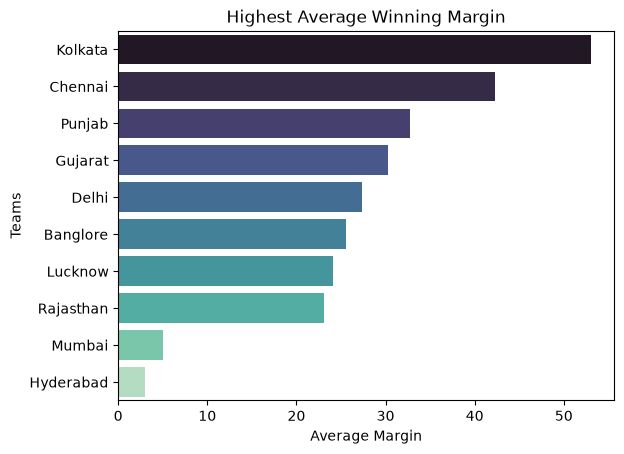

In [130]:
sns.barplot(y=highest_average_win_margin.index,x=highest_average_win_margin.values,palette='mako')
plt.title('Highest Average Winning Margin')
plt.xlabel('Average Margin')
plt.ylabel('Teams')

### Which team had the most Player of the Match winners?

Text(0, 0.5, 'Teams')

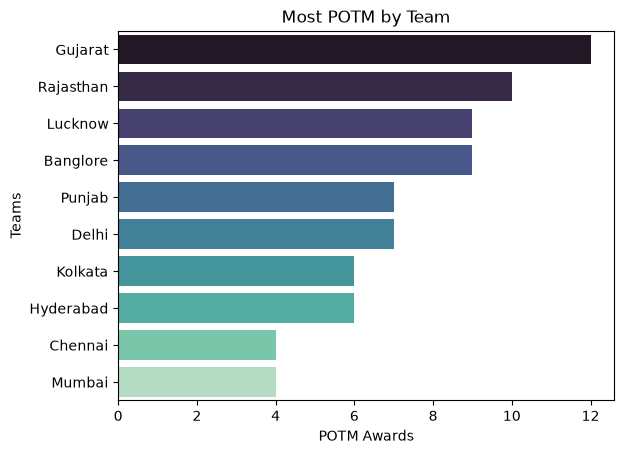

In [138]:
most_POTM_teams=df.groupby('match_winner')['player_of_the_match'].count().sort_values(ascending=False)
sns.barplot(y=most_POTM_teams.index,x=most_POTM_teams.values,palette='mako')
plt.title('Most POTM by Team')
plt.xlabel('POTM Awards')
plt.ylabel('Teams')

### How many unique players won the Player of the Match award?

In [145]:
df['player_of_the_match'].nunique()

56

### Which venue had the highest average total score?

In [149]:
df['total_score']= df['first_ings_score'] + df['second_ings_score']
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets,total_score
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,264
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3,356
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2,413
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3,319
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3,359


In [153]:
avg_total_score=df.groupby('venue')['total_score'].mean().sort_values(ascending=False)
avg_total_score

venue
Eden Gardens, Kolkata                           389.500000
Brabourne Stadium, Mumbai                       341.437500
Dr DY Patil Sports Academy, Mumbai              328.650000
Wankhede Stadium, Mumbai                        328.142857
Maharashtra Cricket Association Stadium,Pune    316.000000
Narendra Modi Stadium, Ahmedabad                290.500000
Name: total_score, dtype: float64

Which venue favored chasing teams?

<Axes: ylabel='venue'>

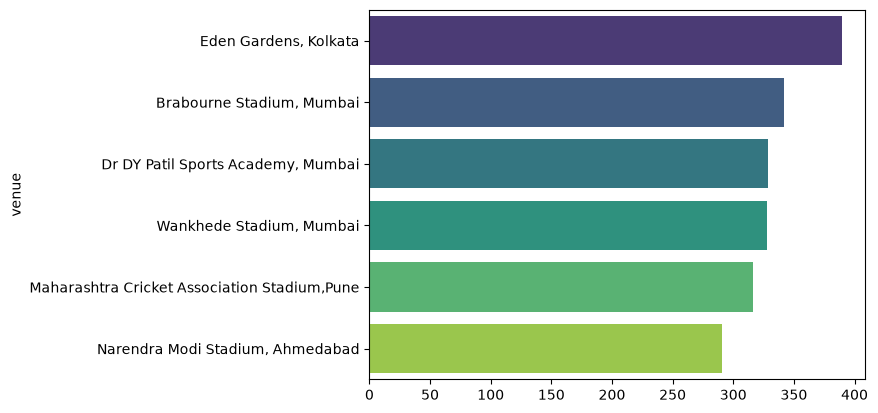

In [154]:
sns.barplot(y=avg_total_score.index,x=avg_total_score.values,palette='viridis')

### Which team had the best win percentage?

Text(0, 0.5, 'Teams')

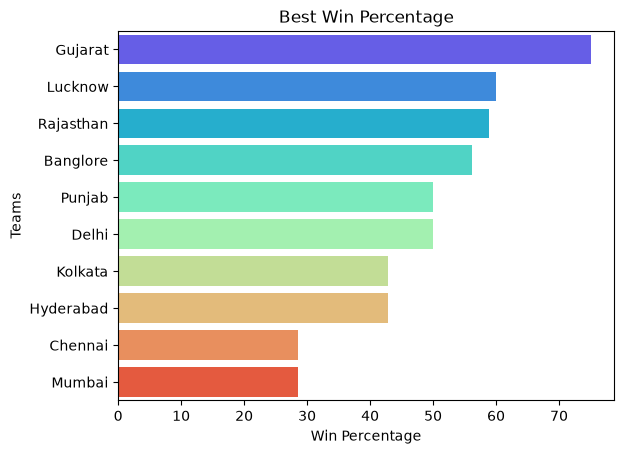

In [169]:
played = pd.concat([df["team1"], df["team2"]]).value_counts()
won=df['match_winner'].value_counts()
win_percentage = ((won/played)*100).sort_values(ascending=False)
sns.barplot(x=win_percentage.values, y=win_percentage.index, palette='rainbow')
plt.title('Best Win Percentage')
plt.xlabel('Win Percentage')
plt.ylabel('Teams')

### Which Player of the Match award was won despite not being the top scorer?

In [157]:
df[df["player_of_the_match"] != df['top_scorer']][['player_of_the_match']]

,player_of_the_match
0,Umesh Yadav
1,Kuldeep Yadav
2,Odean Smith
3,Mohammed Shami
4,Sanju Samson
5,Wanindu Hasaranga
6,Evin Lewis
7,Umesh Yadav
9,Lockie Ferguson
11,Avesh Khan


### Which teams won despite scoring fewer than 150?

In [163]:
df[(df['won_by']=='Runs') & (df['first_ings_score']<150)][['match_winner','first_ings_score']]

,match_winner,first_ings_score
38,Rajasthan,144
56,Gujarat,144


## Advanced Analysis

### Compare average first-innings scores across different stages (League,playoffs).

Text(0.5, 1.0, 'Average First Innings Score')

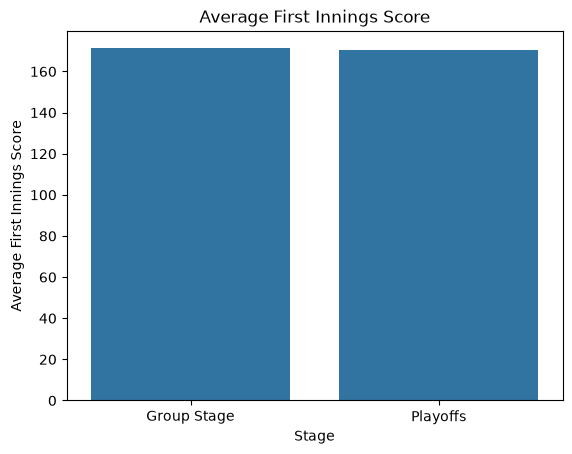

In [184]:
group_stage=df[df['stage']=='Group']['first_ings_score'].mean()
playoffs=df[df['stage'].isin(['Playoff', 'Final'])]['first_ings_score'].mean()
values = [group_stage, playoffs]
labels = ["Group Stage", "Playoffs"]
sns.barplot(x=labels,y=values)
plt.xlabel("Stage")
plt.ylabel("Average First Innings Score")
plt.title('Average First Innings Score')

### Which teams relied more on batting than bowling for victories?

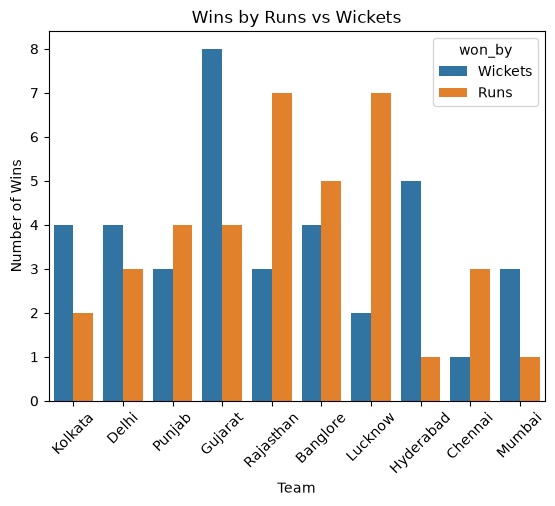

In [191]:
sns.countplot(data=df, x="match_winner", hue="won_by")

plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.title("Wins by Runs vs Wickets")
plt.xticks(rotation=45)
plt.show()

### Which teams won despite losing the toss?

In [190]:
df[df['toss_winner'] != df['match_winner']][['team1','team2','toss_winner','match_winner']]

,team1,team2,toss_winner,match_winner
4,Hyderabad,Rajasthan,Hyderabad,Rajasthan
8,Mumbai,Rajasthan,Mumbai,Rajasthan
9,Delhi,Gujarat,Delhi,Gujarat
10,Chennai,Punjab,Chennai,Punjab
11,Hyderabad,Lucknow,Hyderabad,Lucknow
18,Delhi,Kolkata,Kolkata,Delhi
19,Lucknow,Rajasthan,Lucknow,Rajasthan
21,Banglore,Chennai,Banglore,Chennai
22,Mumbai,Punjab,Mumbai,Punjab
23,Gujarat,Rajasthan,Rajasthan,Gujarat


                                                        Thank YOU